                                                                            In the name of GOD

                                                                               Narges Vali
                                                                                401102791

In [1]:
# 1.1

import pandas as pd

df = pd.read_csv("star.csv")

print("Before encoding:")
print(df.info())
print(df["class"].unique())

class_mapping = {
    "GALAXY": 0,
    "STAR": 1,
    "QSO": 2
}

df["class"] = df["class"].map(class_mapping)

print("After encoding:")
print(df.info())
print(df["class"].value_counts())

df.head()


Before encoding:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237660e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543780e+18,0,0.634794,5812,56354,171
1,1.237660e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176010e+19,0,0.779136,10445,58158,427
2,1.237660e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299
3,1.237660e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030110e+19,0,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891860e+18,0,0.116123,6121,56187,842


In this section, the data from the `star.csv` file was loaded using the `pandas` library, and the overall structure of the dataset was examined using the `info()` function. The results showed that the dataset contains `100,000` samples and `18` features. Then, the `class` column, which originally contained the textual labels `GALAXY`, `STAR`, and `QSO`, was converted into numerical values according to the assignment requirements. Specifically, `GALAXY` was mapped to `0`, `STAR` was mapped to `1`, and `QSO` was mapped to `2`, where `QSO` represents Quasar. Finally, by rechecking the dataset and observing the values in the `class` column, the correctness of the encoding process was confirmed.

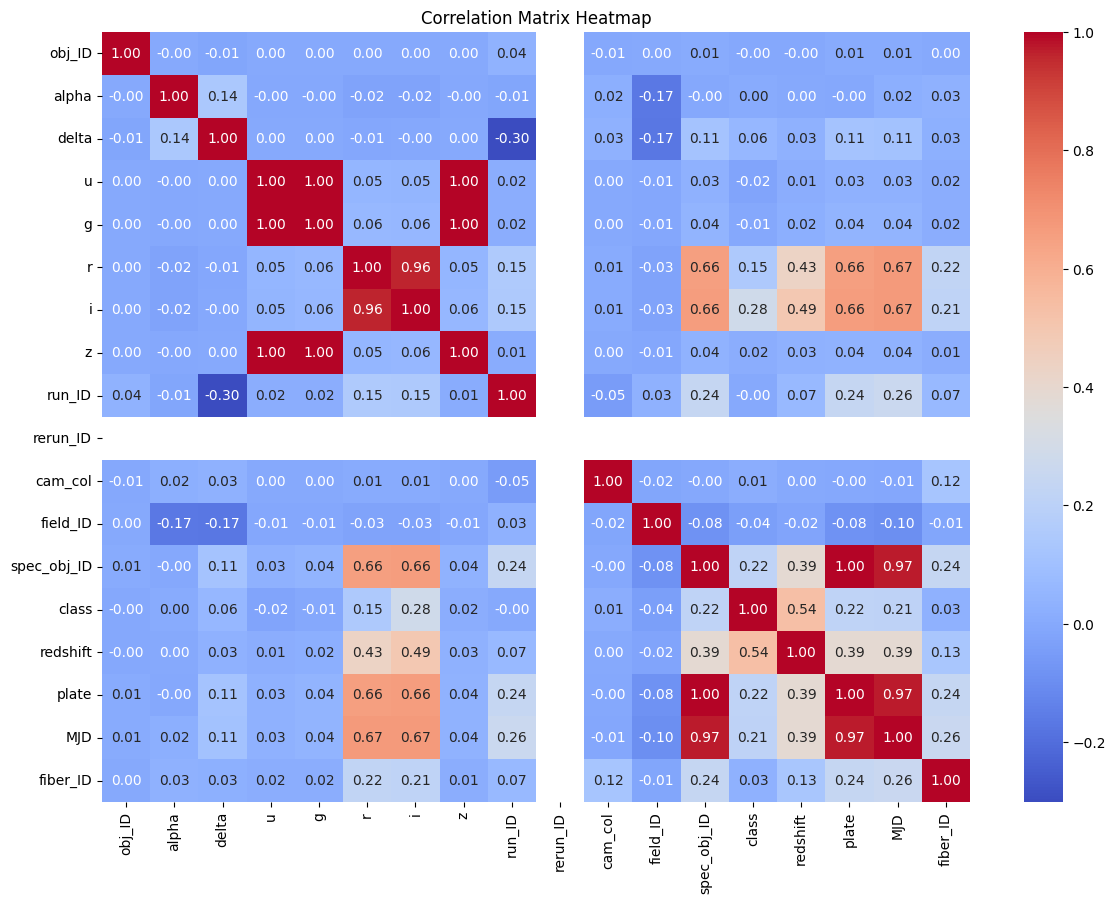

Correlation with class:
class          1.000000
redshift       0.536822
i              0.284396
plate          0.215722
spec_obj_ID    0.215702
MJD            0.207262
r              0.150691
delta          0.056643
fiber_ID       0.032053
z              0.017352
cam_col        0.014476
alpha          0.004552
run_ID        -0.000049
obj_ID        -0.002440
g             -0.005915
u             -0.017701
field_ID      -0.038044
rerun_ID            NaN
Name: class, dtype: float64

Absolute correlation with class:
class          1.000000
redshift       0.536822
i              0.284396
plate          0.215722
spec_obj_ID    0.215702
MJD            0.207262
r              0.150691
delta          0.056643
field_ID       0.038044
fiber_ID       0.032053
u              0.017701
z              0.017352
cam_col        0.014476
g              0.005915
alpha          0.004552
obj_ID         0.002440
run_ID         0.000049
rerun_ID            NaN
Name: class, dtype: float64

Features with very lo

In [2]:
#1.2

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

# Show correlation of each feature with the target column class
class_corr = corr_matrix["class"].sort_values(ascending=False)
print("Correlation with class:")
print(class_corr)

# Use absolute correlation values to consider both positive and negative correlations
class_corr_abs = corr_matrix["class"].abs().sort_values(ascending=False)
print("\nAbsolute correlation with class:")
print(class_corr_abs)

# Select features with very low correlation with class
# The threshold can be changed if needed
threshold = 0.05

low_corr_features = class_corr_abs[class_corr_abs < threshold].index.tolist()

# Make sure the target column itself is not removed
if "class" in low_corr_features:
    low_corr_features.remove("class")

print("\nFeatures with very low correlation with class:")
print(low_corr_features)

# Remove low-correlation features from the dataset
df_reduced = df.drop(columns=low_corr_features)

print("\nOriginal dataset shape:")
print(df.shape)

print("\nReduced dataset shape:")
print(df_reduced.shape)

print("\nRemaining columns:")
print(df_reduced.columns)


In this section, the correlation matrix of the dataset was computed and visualized using a heatmap. Then, the correlation of each feature with the target variable `class` was examined. Based on the absolute correlation values and using a threshold of 0.05, features with very weak correlation to the target were removed. The results showed that `redshift` had the highest correlation with the target variable, followed by `i`, `plate`, `spec_obj_ID`, `MJD`, `r`, and `delta`. Therefore, only these relatively relevant features were retained for the next steps of analysis.

Class distribution before under-sampling:
class
0    59445
1    21594
2    18961
Name: count, dtype: int64


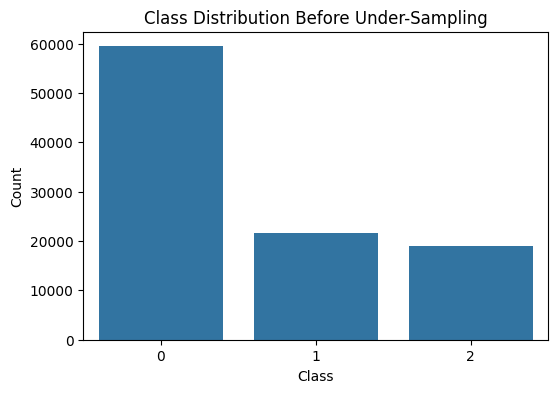

Class distribution after under-sampling:
class
2    6666
0    6666
1    6666
Name: count, dtype: int64

Balanced dataset shape:
(19998, 9)


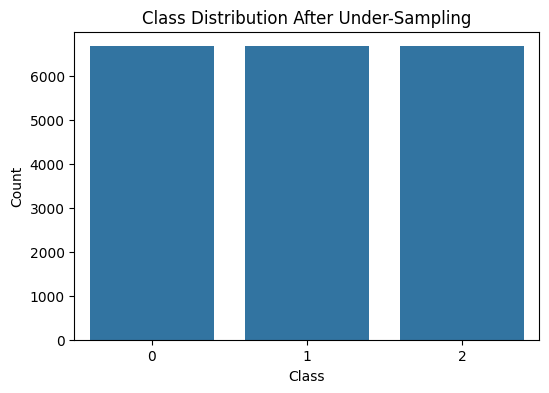

X shape: (19998, 8)
y shape: (19998,)


In [12]:
#1.3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the reduced dataset from the correlation analysis step
data = df_reduced.copy()

# Make sure column names are clean
data.columns = data.columns.str.strip()

# Check class distribution before balancing
print("Class distribution before under-sampling:")
print(data["class"].value_counts())

# Plot class distribution before balancing
plt.figure(figsize=(6, 4))
sns.countplot(x="class", data=data)
plt.title("Class Distribution Before Under-Sampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Select equal number of samples from each class
# 6666 samples per class gives approximately 20,000 total samples
samples_per_class = 6666

class_0 = data[data["class"] == 0].sample(n=samples_per_class, random_state=42)
class_1 = data[data["class"] == 1].sample(n=samples_per_class, random_state=42)
class_2 = data[data["class"] == 2].sample(n=samples_per_class, random_state=42)

# Combine the selected samples
balanced_data = pd.concat([class_0, class_1, class_2], axis=0)

# Shuffle the balanced dataset
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Check class distribution after balancing
print("Class distribution after under-sampling:")
print(balanced_data["class"].value_counts())

print("\nBalanced dataset shape:")
print(balanced_data.shape)

# Plot class distribution after balancing
plt.figure(figsize=(6, 4))
sns.countplot(x="class", data=balanced_data)
plt.title("Class Distribution After Under-Sampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Prepare features and target for model training
X = balanced_data.drop("class", axis=1)
y = balanced_data["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)


Before applying under-sampling, the dataset was imbalanced. Class 0 had 59,445 samples, Class 1 had 21,594 samples, and Class 2 had 18,961 samples. To balance the dataset, 6,666 samples were randomly selected from each class. After under-sampling, each class contained exactly 6,666 samples, resulting in a balanced dataset with 19,998 rows and 9 columns. Finally, the feature matrix X and target vector y were created. X has the shape (19998, 8), and y has the shape (19998,).

In [14]:
#1.4

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (15998, 8)
X_test shape: (4000, 8)
y_train shape: (15998,)
y_test shape: (4000,)


In this step, the feature matrix was standardized using StandardScaler to ensure all features contribute equally to the model training. Afterward, the dataset was split into training (80%) and testing (20%) sets. A stratified split was used to maintain the class balance across both sets. The final training set contains 15,998 samples, and the test set contains 4,000 samples, each with 8 features.


--- Evaluation for C = 0.1 ---
Accuracy: 0.9260
Recall (Macro): 0.9260
F1-Score (Macro): 0.9255


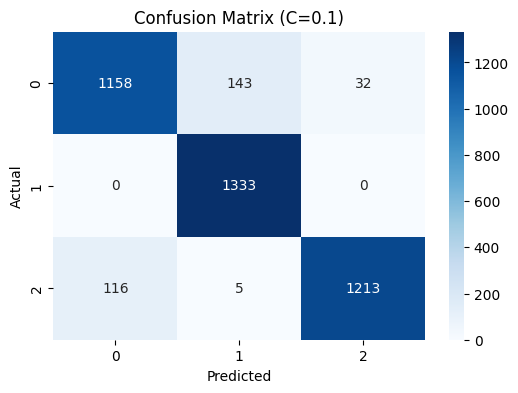

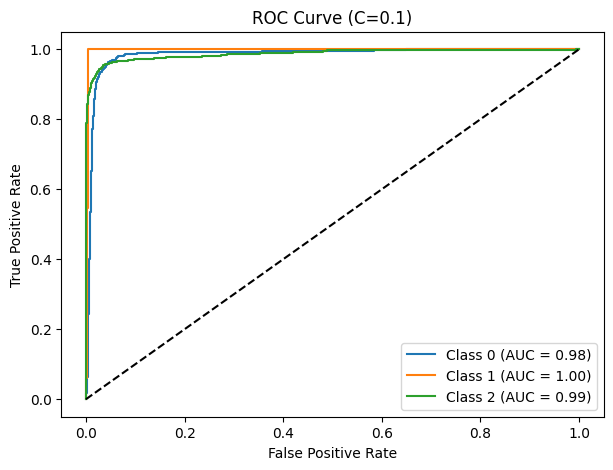


--- Evaluation for C = 1 ---
Accuracy: 0.9533
Recall (Macro): 0.9533
F1-Score (Macro): 0.9531


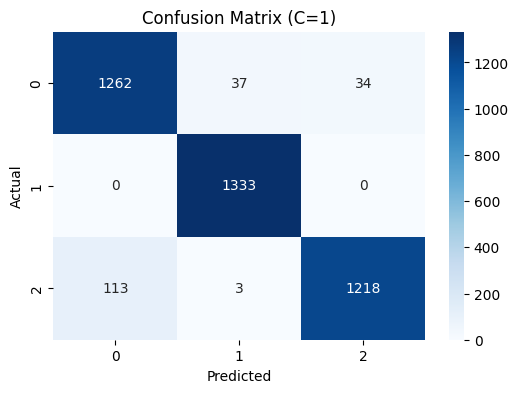

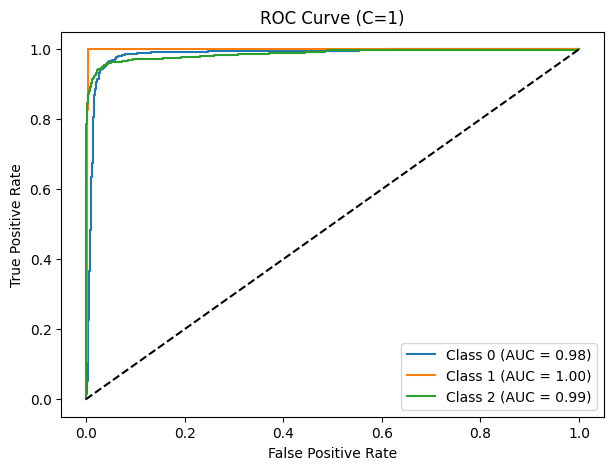


--- Evaluation for C = 10 ---
Accuracy: 0.9585
Recall (Macro): 0.9585
F1-Score (Macro): 0.9584


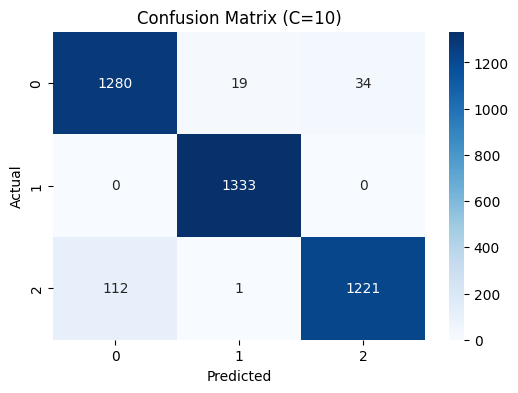

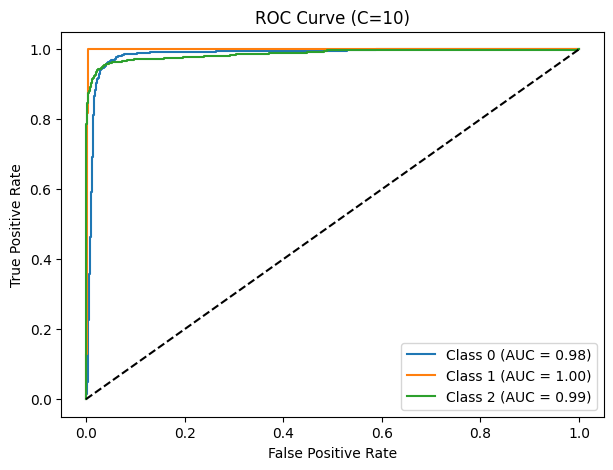

In [15]:
#1.5

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of C values to evaluate
C_values = [0.1, 1, 10]

for c in C_values:
    print(f"\n--- Evaluation for C = {c} ---")
    
    # Create and train the SVM model with a linear kernel
    # probability=True is required for ROC curve plotting
    svm_model = SVC(kernel='linear', C=c, probability=True, random_state=42)
    svm_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = svm_model.predict(X_test)
    y_score = svm_model.predict_proba(X_test)
    
    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall (Macro): {rec:.4f}")
    print(f"F1-Score (Macro): {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (C={c})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # Plot ROC curve using One-vs-Rest for multi-class classification
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    n_classes = 3
    
    plt.figure(figsize=(7, 5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve (C={c})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()


A Support Vector Machine (SVM) with a linear kernel was implemented for multi-class classification. The model was evaluated using three different regularization values for C: 0.1, 1, and 10. For each configuration, performance was assessed using a confusion matrix, accuracy, macro-averaged recall, and F1-score. Additionally, ROC curves and AUC values were generated for each class to analyze the model's diagnostic ability. The results indicate how the penalty parameter C influences the decision boundary and overall classification performance.

Accuracy: 0.9425
Recall (Macro): 0.9425
F1-Score (Macro): 0.9422


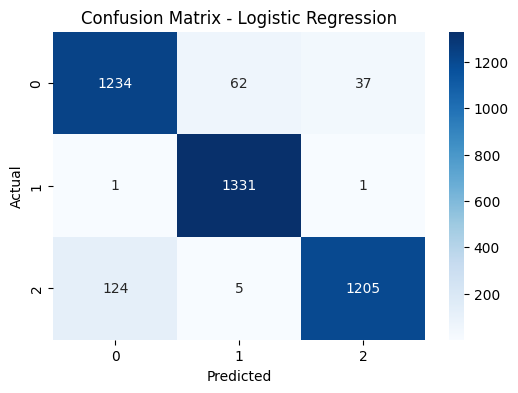

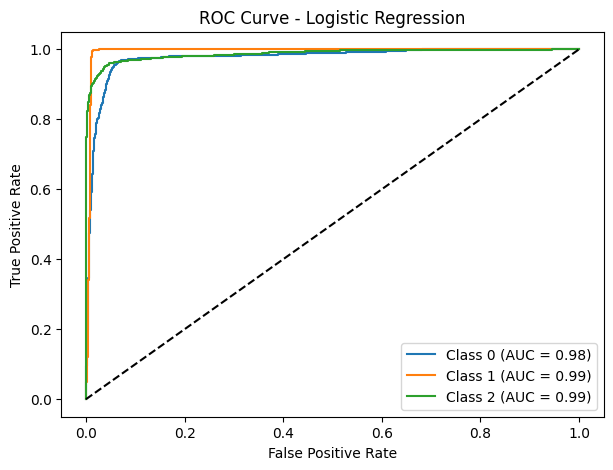

In [16]:
#1.6

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Create and train the Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Make predictions
y_pred = log_model.predict(X_test)
y_score = log_model.predict_proba(X_test)

# Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"Recall (Macro): {rec:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve using One-vs-Rest for multi-class classification
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

plt.figure(figsize=(7, 5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


In this step, a Logistic Regression model was trained on the standardized training data and evaluated on the test set. The model performance was measured using accuracy, macro-averaged recall, and F1-score. In addition, a confusion matrix was plotted to visualize classification errors, and ROC curves were generated for each class using the One-vs-Rest approach. These results provide an overall view of the classification capability of Logistic Regression on the balanced dataset.

Coefficients for each class:
               delta         r         i  rerun_ID  spec_obj_ID   redshift  \
Galaxy (0) -0.059617  2.013804 -2.097740       0.0     0.226732   9.466621   
Star (1)   -0.075932  1.459766 -0.920196       0.0    -0.371766 -23.903088   
Quasar (2)  0.135549 -3.473570  3.017936       0.0     0.145034  14.436467   

               plate       MJD  
Galaxy (0)  0.218023 -0.519505  
Star (1)   -0.369234  0.973929  
Quasar (2)  0.151211 -0.454424  


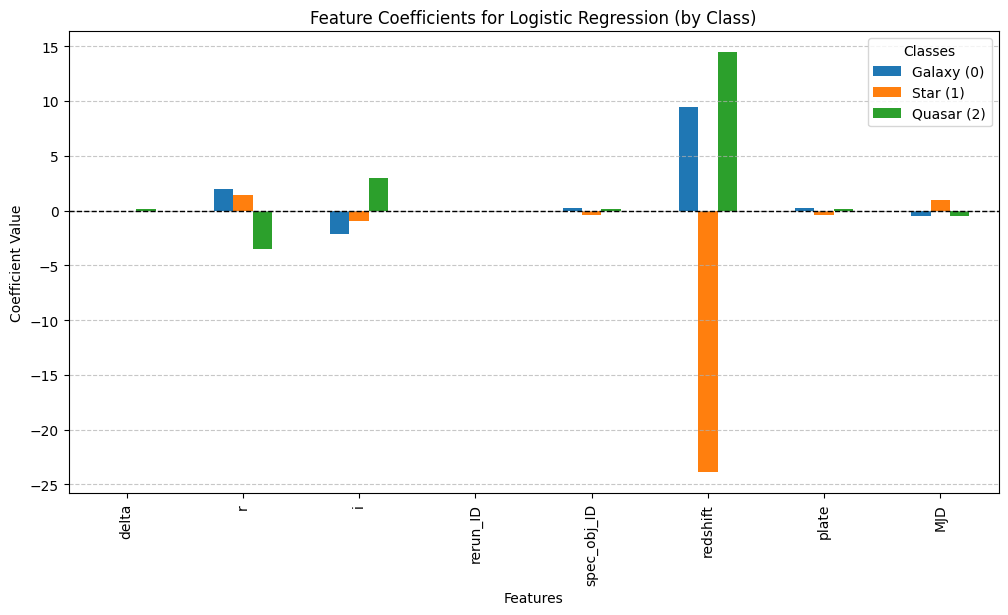

In [17]:
#1.7

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature names from your X dataframe (before scaling)
feature_names = X.columns 

# Get the coefficients from the logistic regression model
# log_model.coef_ has shape (n_classes, n_features)
coefficients = log_model.coef_

# Create a DataFrame for better visualization
coef_df = pd.DataFrame(coefficients, columns=feature_names, index=['Galaxy (0)', 'Star (1)', 'Quasar (2)'])

print("Coefficients for each class:")
print(coef_df)

# Plotting the coefficients to see feature importance
coef_df.T.plot(kind='bar', figsize=(12, 6))
plt.title('Feature Coefficients for Logistic Regression (by Class)')
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend(title='Classes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In this step, the coefficients of the Logistic Regression model were analyzed to examine the relationship between each feature and the output classes. Since the features were standardized before training, the coefficient magnitudes can be directly compared to determine feature importance.

Based on the obtained coefficients, `redshift` is the most important feature in the model because it has the largest absolute coefficient values across all classes. Its coefficient is 9.4666 for Galaxy, -23.9031 for Star, and 14.4365 for Quasar. This indicates that `redshift` plays the most significant role in separating the classes. A positive coefficient for Galaxy and Quasar means that higher values of `redshift` increase the likelihood of belonging to these classes, while the strongly negative coefficient for Star shows that higher `redshift` values greatly reduce the probability of a sample being classified as a Star.

After `redshift`, the features `r` and `i` appear to be the next most influential variables. Their coefficients show noticeable positive and negative contributions depending on the class, which means they also help the model distinguish between astronomical objects. However, their impact is still much smaller than that of `redshift`.

On the other hand, features such as `delta`, `spec_obj_ID`, `plate`, and `MJD` have relatively small coefficients, indicating weaker contributions to the classification process. In particular, `rerun_ID` has a coefficient close to zero, which suggests that it has almost no effect on the model's predictions.

Overall, the results show that `redshift` is the most significant feature, followed by `r` and `i`, while `rerun_ID` is the least important feature. The sign of each coefficient indicates whether the feature increases or decreases the probability of belonging to a specific class.